In [1]:
import pandas as pd

data = pd.read_csv("../data/processed_data.csv")

print(data.shape)


# One Hot Encoding
data = pd.get_dummies(data,columns=["Type", "Store", "IsHoliday"],drop_first=True)

data["Date"] = pd.to_datetime(data["Date"])

data = data.sort_values("Date").reset_index(drop=True)

X = data.drop(["Weekly_Sales", "Date"], axis=1)
y = data["Weekly_Sales"]


split_index = int(len(data) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


# Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV , TimeSeriesSplit

model = RandomForestRegressor(random_state=42)
tscv = TimeSeriesSplit(n_splits=3)

params = {
    "n_estimators": [50, 100],
    "max_depth": [10,None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

random_search = RandomizedSearchCV(estimator=model,param_distributions=params,n_iter=10,cv=tscv,random_state=42,n_jobs=1,verbose=2)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Score:")
print(random_search.best_score_)

(421570, 19)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  11.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  17.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  22.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  24.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   5.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_esti

In [2]:
import joblib

best_rf = random_search.best_estimator_

joblib.dump(best_rf, "../models/best_random_forest.pkl")

print("Random Forest model saved!")

y_pred = best_rf.predict(X_test)
print("Predict sales")
print(y_pred[:10])

Random Forest model saved!
Predict sales
[20949.4833 58476.7017 12576.2197  2333.9121 55491.4201  7531.8073
 12213.8371  1377.7822 13605.1214  2174.8771]


In [6]:
comparsion = pd.DataFrame({"actual_sales" : y_test.values,"predicted_sales" :y_pred })
print(comparsion.head(10))

   actual_sales  predicted_sales
0      25890.80       20949.4833
1      91691.90       58476.7017
2      28446.31       12576.2197
3       1943.18        2333.9121
4       7563.94       55491.4201
5      10434.61        7531.8073
6      14368.12       12213.8371
7          7.97        1377.7822
8       2749.30       13605.1214
9       2019.50        2174.8771


In [7]:
from sklearn.metrics import  mean_squared_error,mean_absolute_error,r2_score
import numpy as np

r_mae = mean_absolute_error(y_test,y_pred)
r_mse = mean_squared_error(y_test,y_pred)
r_r2 =  r2_score(y_test ,y_pred)

print("MSE" , r_mse)
print("MAE" , r_mae)
print("R2_score",r_r2)

MSE 67500712.16711941
MAE 5182.5316127819815
R2_score 0.8598620244238635


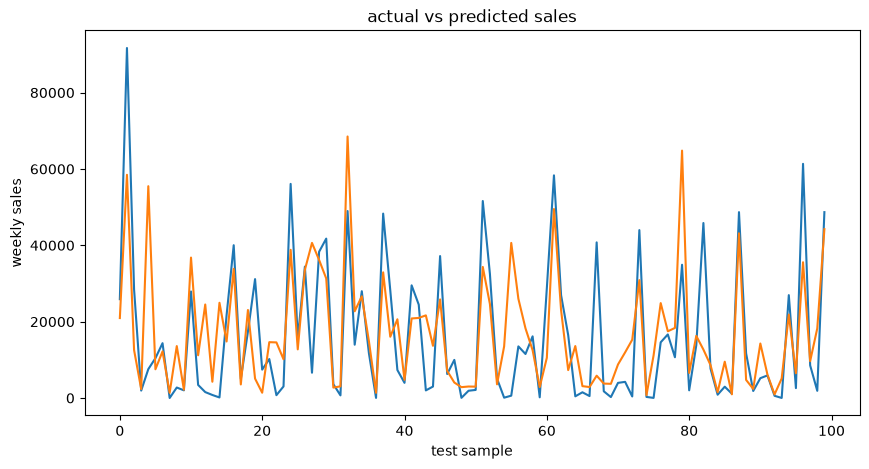

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100] , label = "actual sales")
plt.plot(y_pred[:100], label ="predicted sales")

plt.xlabel("test sample")
plt.ylabel("weekly sales")
plt.title("actual vs predicted sales")

plt.show()